<a href="https://colab.research.google.com/github/vandanacm/spring-quarter-2026/blob/main/EEC289Q_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 3 — Decision Trees, Random Forests, Clustering, and kNN

This notebook implements Supervised learning sections use the Wisconsin Breast Cancer *(Diagnostic)* dataset from `sklearn`. Clustering uses `EastWestAirlines.xlsx`. The kNN section uses the UCI Wisconsin Breast Cancer CSV.


In [ ]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q openpyxl

import json
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    silhouette_score,
)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer

from scipy.cluster.hierarchy import dendrogram, linkage

REPORT_DIR = Path("_hw3_report_out")
REPORT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.titlecolor": "black",
    }
)

AIRLINE_XLSX = "EastWestAirlines.xlsx"
UCI_BC_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

RANDOM_STATE_SPLIT = 42
KMEANS_RANDOM_STATE = 2

REPORT_METRICS = {}


def savefig(name):
    plt.savefig(REPORT_DIR / name, dpi=160, bbox_inches="tight", facecolor="white")

## Part A — Decision tree

The data are split before any model is fit so that depth selection is judged on held-out patients rather than training error. A stratified split keeps the benign–malignant ratio stable across folds, which matters when class balance is mildly uneven.

It fixes `criterion="entropy"`, so each split maximizes the expected reduction in Shannon entropy. Depth limits model capacity, shallow trees underfit, deep trees can overfit.

Precision, recall, and F1 are reported with `pos_label=0` because, in `load_breast_cancer`, label `0` denotes malignant and `1` benign. That convention makes the three scores read as performance on detecting malignancy.

In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE_SPLIT, stratify=y
)

depths = range(1, 11)
rows = []
models_by_depth = {}
for depth in depths:
    dt = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=RANDOM_STATE_SPLIT,
        min_samples_leaf=1,
    )
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    rows.append(
        {
            "max_depth": depth,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, pos_label=0, zero_division=0),
            "recall": recall_score(y_test, y_pred, pos_label=0, zero_division=0),
            "f1": f1_score(y_test, y_pred, pos_label=0, zero_division=0),
        }
    )
    models_by_depth[depth] = dt

dt_metrics = pd.DataFrame(rows)
display(dt_metrics)

best_acc = dt_metrics["accuracy"].max()
candidates = dt_metrics.loc[dt_metrics["accuracy"] == best_acc, "max_depth"].tolist()
best_depth = int(min(candidates))
optimal_dt = models_by_depth[best_depth]
REPORT_METRICS["decision_tree"] = {
    "metrics_by_depth": dt_metrics.to_dict(orient="records"),
    "best_depth": best_depth,
    "best_test_accuracy": float(best_acc),
}
print(f"Optimal max_depth, max test accuracy; shallow tie-break: {best_depth}")

,max_depth,accuracy,precision,recall,f1
0,1,0.921053,0.923077,0.857143,0.888889
1,2,0.894737,0.800000,0.952381,0.869565
2,3,0.947368,0.950000,0.904762,0.926829
3,4,0.938596,0.906977,0.928571,0.917647
4,5,0.929825,0.869565,0.952381,0.909091
5,6,0.912281,0.833333,0.952381,0.888889
6,7,0.912281,0.833333,0.952381,0.888889
7,8,0.912281,0.833333,0.952381,0.888889
8,9,0.912281,0.833333,0.952381,0.888889
9,10,0.912281,0.833333,0.952381,0.888889


Optimal max_depth, max test accuracy; shallow tie-break: 3


### Confusion matrices across depths

Each panel summarizes test-set errors at one depth. The off-diagonal counts show whether mistakes are dominated by false benign predictions or false malignant predictions.


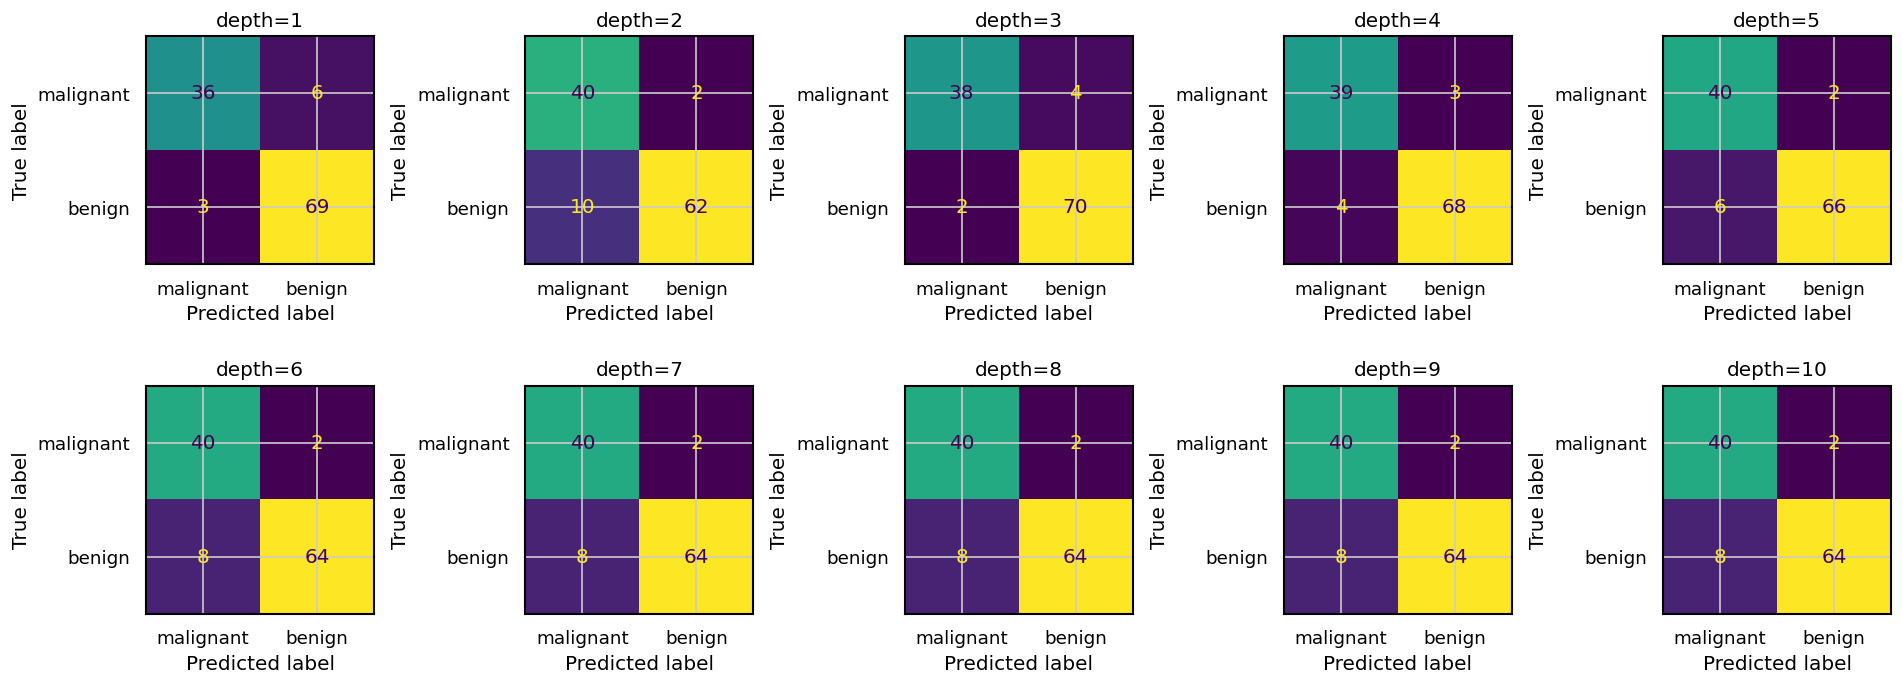

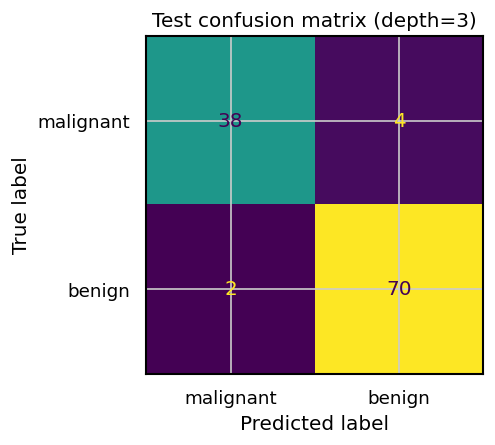

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.ravel()
for ax, depth in zip(axes, depths):
    y_pred = models_by_depth[depth].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"depth={depth}")
plt.tight_layout()
savefig("fig_dt_confusion_all_depths.png")
plt.show()

fig, ax = plt.subplots(figsize=(4.2, 4))
y_pred_best = optimal_dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(ax=ax, colorbar=False)
ax.set_title(f"Test confusion matrix (depth={best_depth})")
plt.tight_layout()
savefig("fig_dt_confusion_best.png")
plt.show()

### Optimal tree and feature importances

The tree is plotted at large figure size so node labels remain legible. Importances summarize how much each feature contributed to impurity reduction across the fitted tree; they support interpretation but do not establish causality.


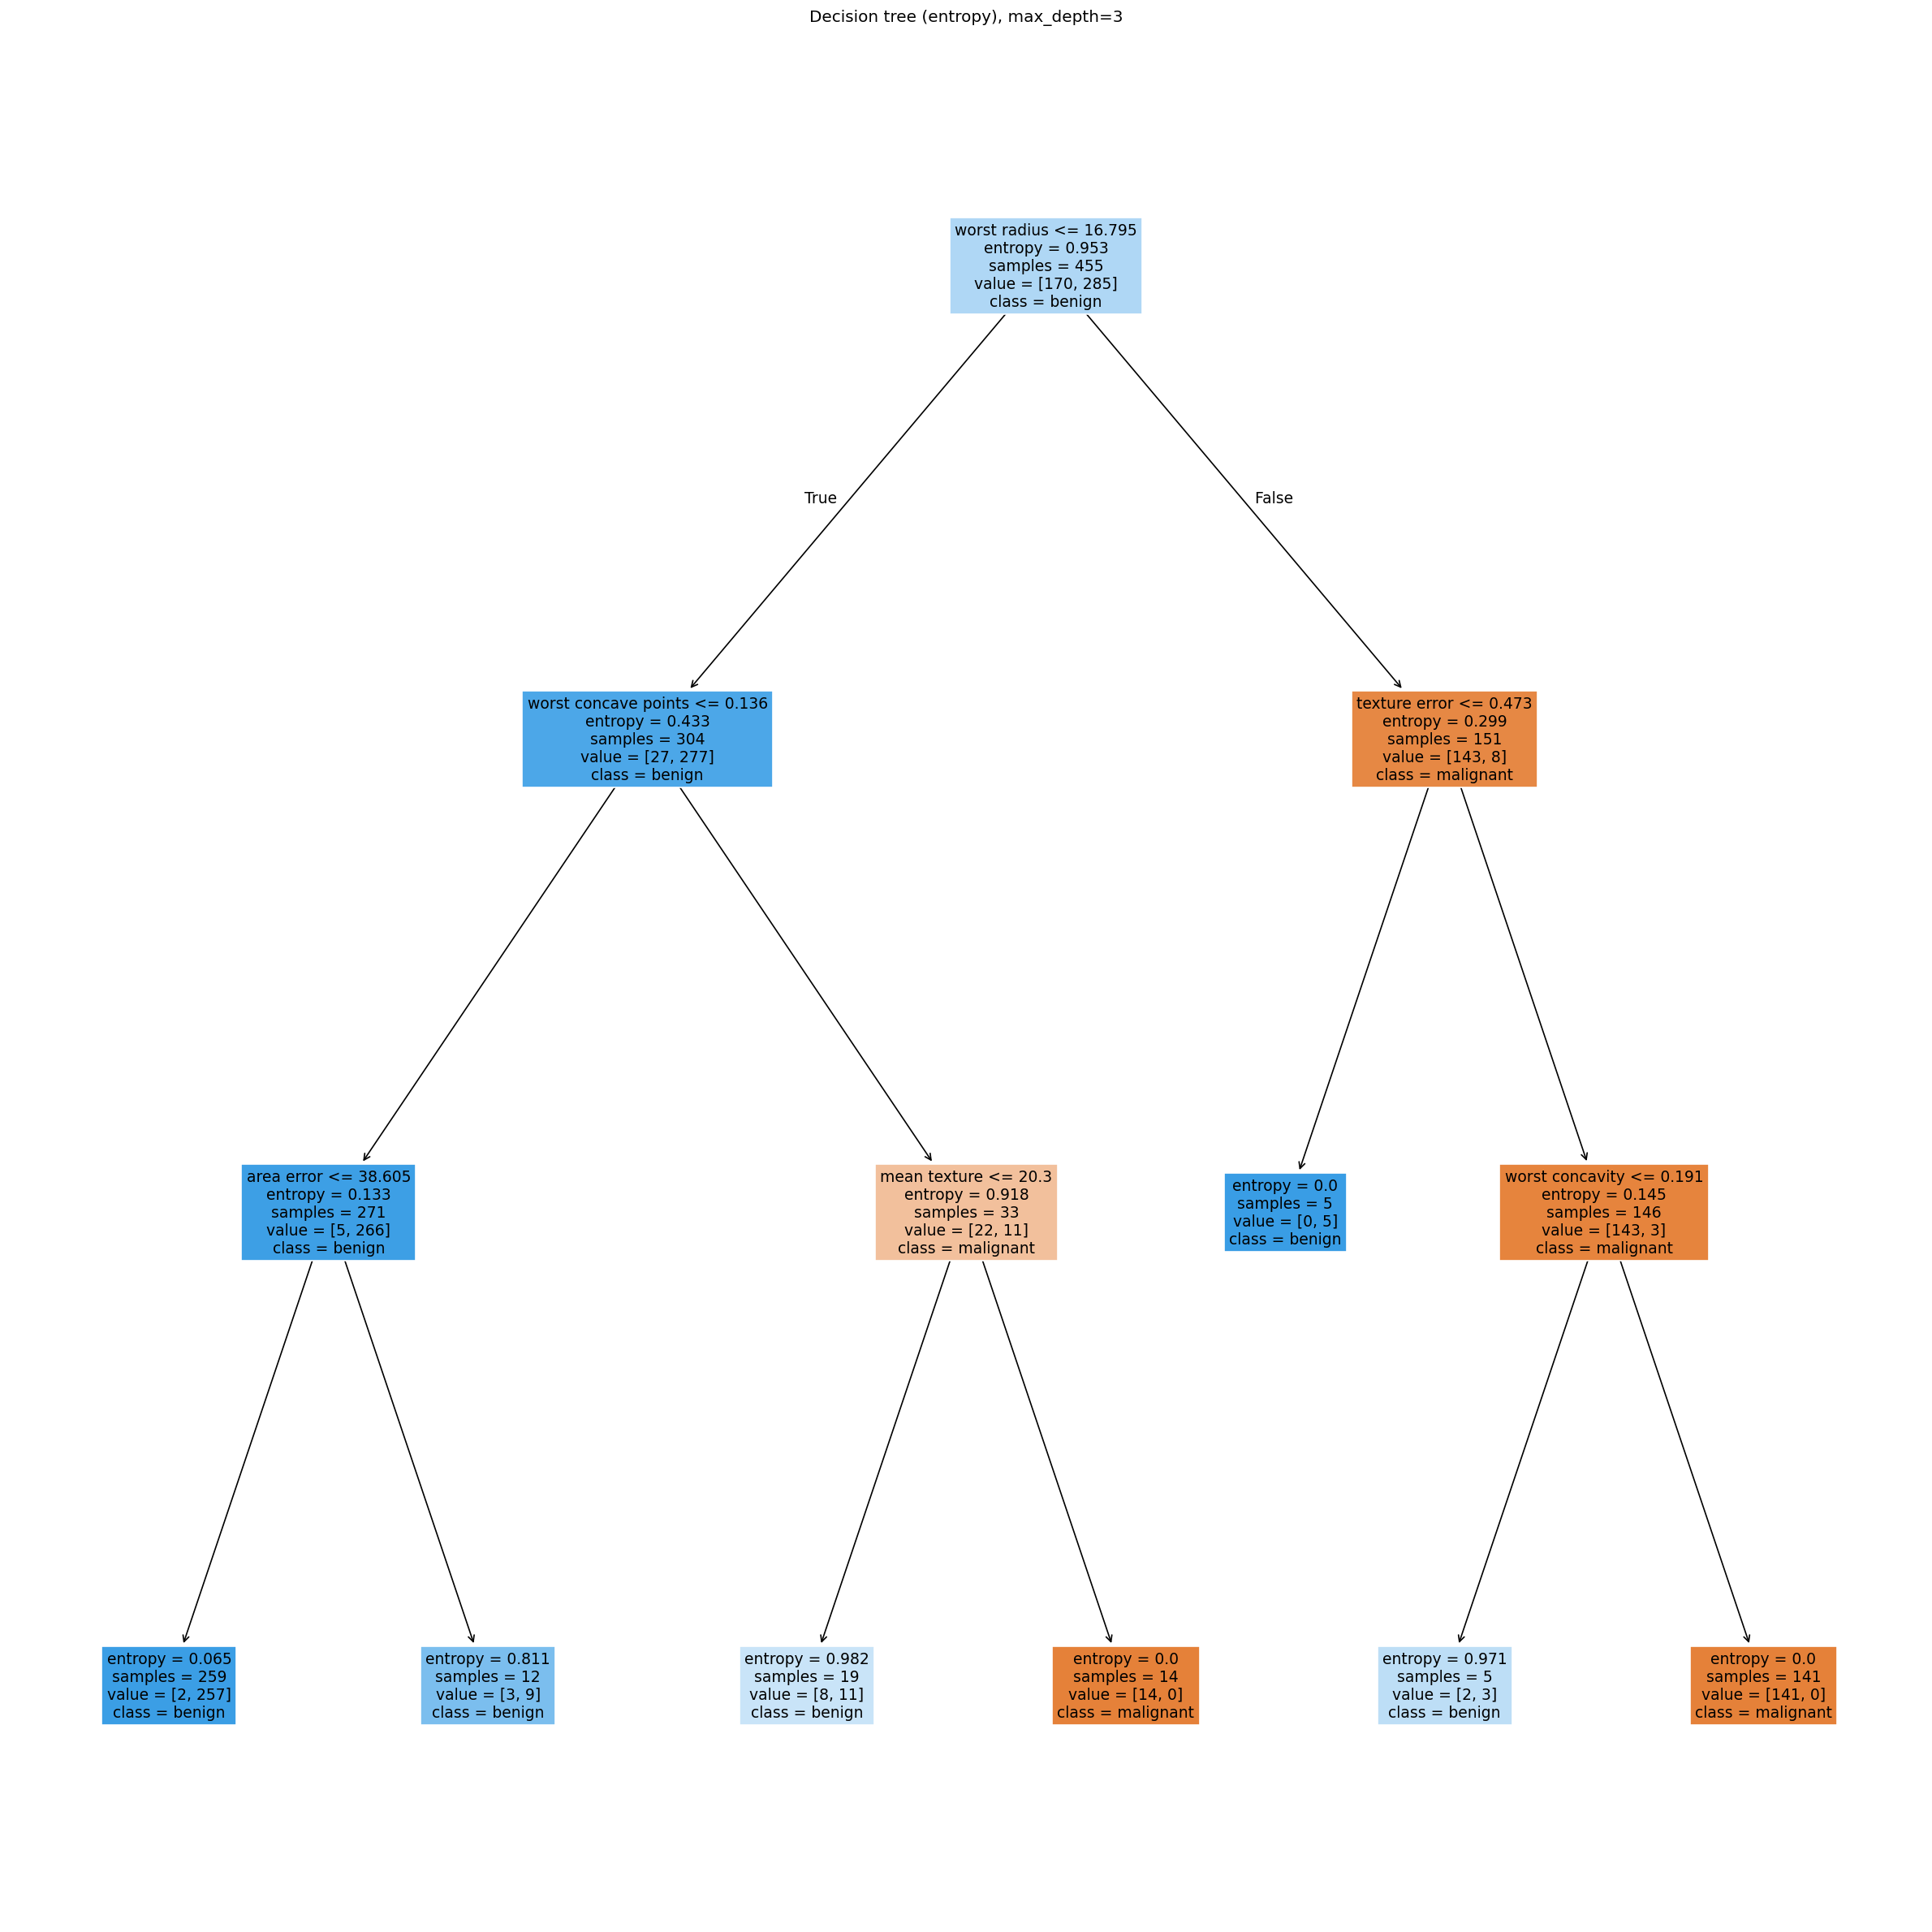

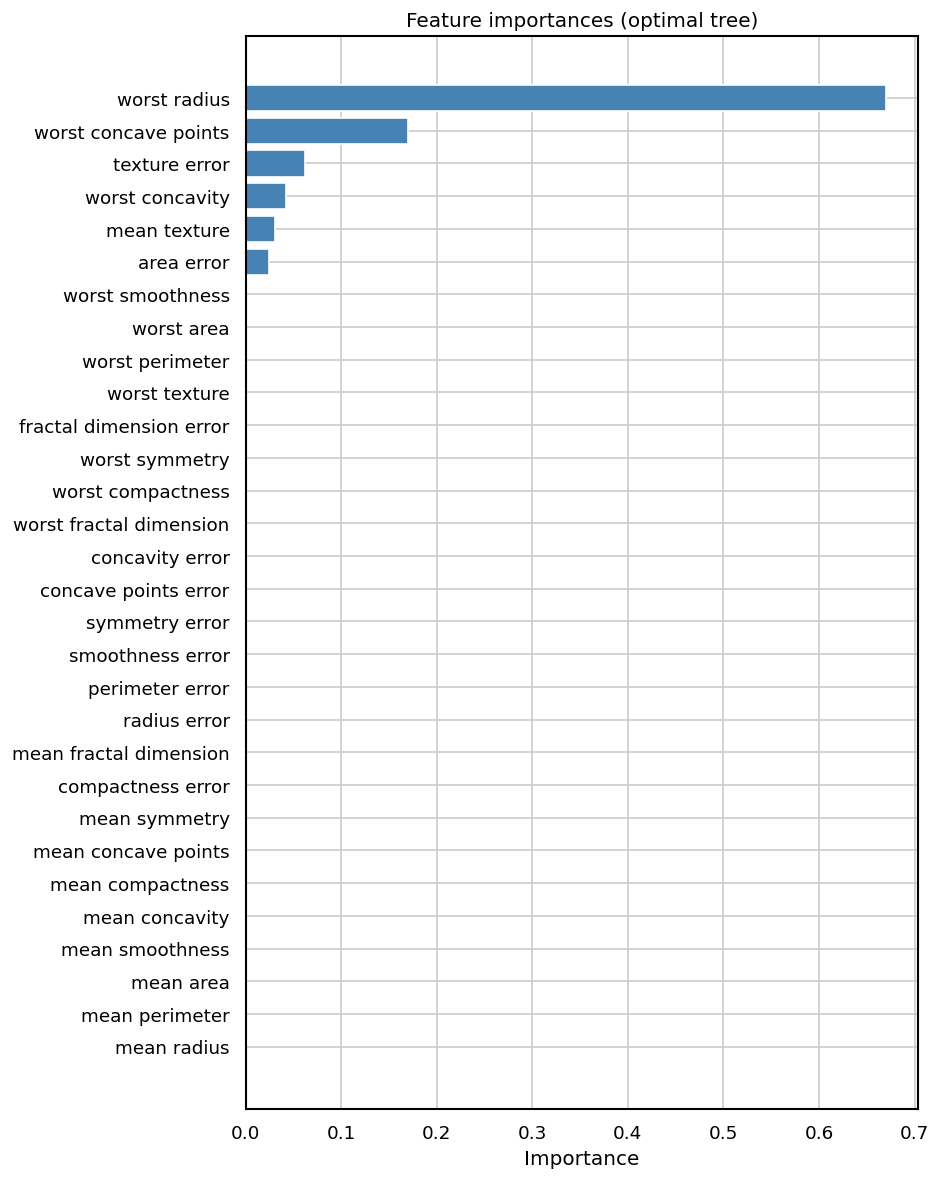

In [ ]:
plt.figure(figsize=(20, 20))
plot_tree(
    optimal_dt,
    feature_names=data.feature_names,
    class_names=list(data.target_names),
    filled=True,
)
plt.title(f"Decision tree (entropy), max_depth={best_depth}")
plt.tight_layout()
savefig("fig_dt_tree.png")
plt.show()

plt.figure(figsize=(8, 10))
order = np.argsort(optimal_dt.feature_importances_)
plt.barh(np.array(data.feature_names)[order], optimal_dt.feature_importances_[order], color="steelblue")
plt.xlabel("Importance")
plt.title("Feature importances (optimal tree)")
plt.tight_layout()
savefig("fig_dt_importances.png")
plt.show()

### Decision trees Summary

Depth controls bias and variance. On this stratified split, test accuracy rises as the tree is allowed more structure, then levels off or dips slightly when depth becomes large enough to chase noise. The confusion matrices show that the dominant failure mode at modest depth is usually a small number of malignant cases misclassified as benign, which is the error type clinicians worry about most.

---

## Part B — Random forest (entropy)
Random forests average many high-variance trees fit on bootstrap samples with random feature subsets at each split, which typically lowers variance relative to a single deep tree. `n_jobs=-1` uses all cores for training without changing the model definition.


In [ ]:
n_list = [1, 5, 10, 15, 20]
rf_rows = []
rf_by_n = {}
for n in n_list:
    rf = RandomForestClassifier(
        criterion="entropy",
        n_estimators=n,
        random_state=RANDOM_STATE_SPLIT,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    rf_rows.append(
        {
            "n_estimators": n,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, pos_label=0, zero_division=0),
            "recall": recall_score(y_test, y_pred, pos_label=0, zero_division=0),
            "f1": f1_score(y_test, y_pred, pos_label=0, zero_division=0),
        }
    )
    rf_by_n[n] = rf

rf_metrics = pd.DataFrame(rf_rows)
display(rf_metrics)
REPORT_METRICS["random_forest"] = {
    "metrics_by_n": rf_metrics.to_dict(orient="records"),
    "best_n_estimators_test_accuracy": int(
        rf_metrics.loc[rf_metrics["accuracy"].idxmax(), "n_estimators"]
    ),
}

,n_estimators,accuracy,precision,recall,f1
0,1,0.938596,0.906977,0.928571,0.917647
1,5,0.947368,0.928571,0.928571,0.928571
2,10,0.956140,0.951220,0.928571,0.939759
3,15,0.964912,0.975000,0.928571,0.951220
4,20,0.964912,0.975000,0.928571,0.951220


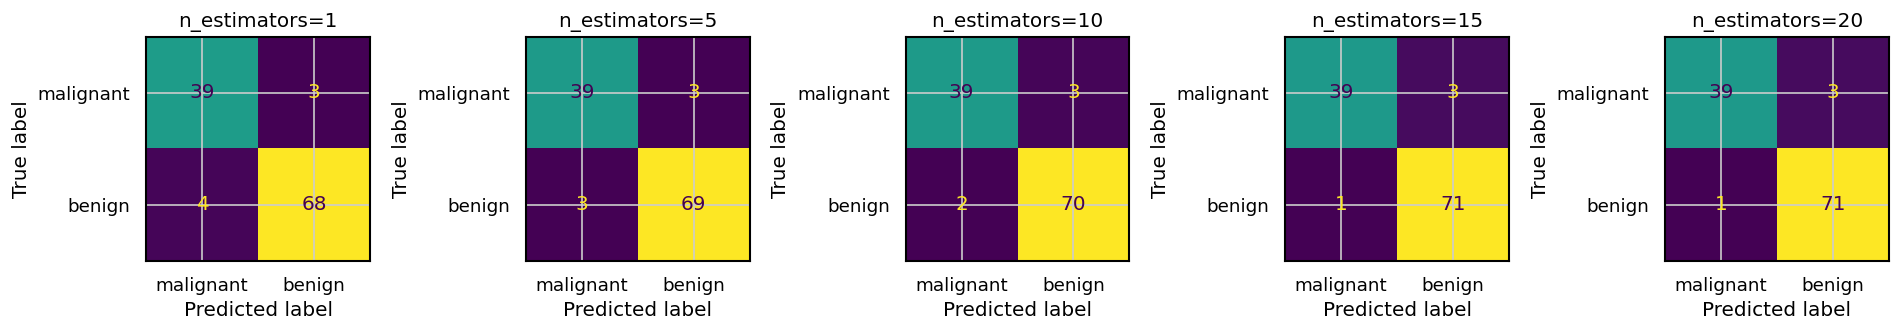

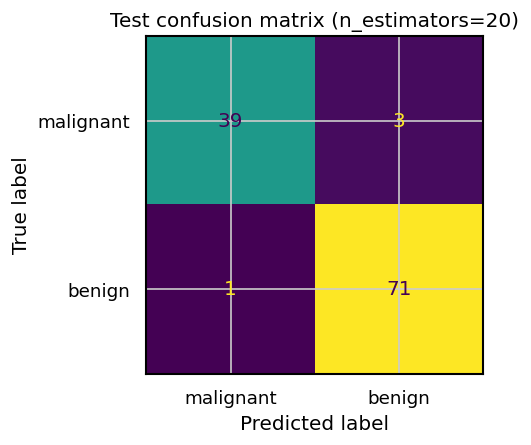

In [ ]:
fig, axes = plt.subplots(1, len(n_list), figsize=(3.2 * len(n_list), 3.5))
for ax, n in zip(axes, n_list):
    y_pred = rf_by_n[n].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"n_estimators={n}")
plt.tight_layout()
savefig("fig_rf_confusion_all.png")
plt.show()

fig, ax = plt.subplots(figsize=(4.2, 4))
y_pred_20 = rf_by_n[20].predict(X_test)
cm = confusion_matrix(y_test, y_pred_20)
ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(ax=ax, colorbar=False)
ax.set_title("Test confusion matrix (n_estimators=20)")
plt.tight_layout()
savefig("fig_rf_confusion_20.png")
plt.show()

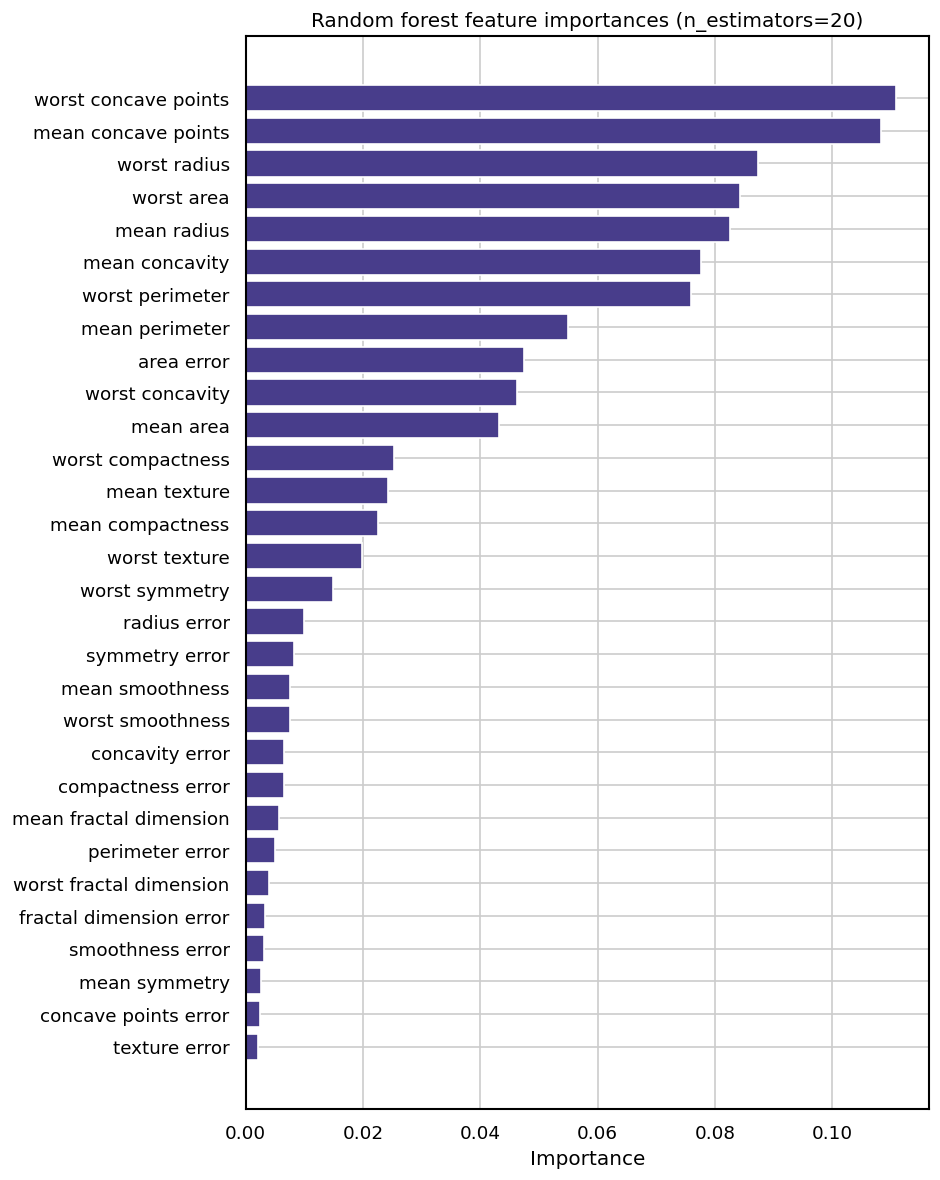

In [ ]:
rf20 = rf_by_n[20]
plt.figure(figsize=(8, 10))
order = np.argsort(rf20.feature_importances_)
plt.barh(np.array(data.feature_names)[order], rf20.feature_importances_[order], color="darkslateblue")
plt.xlabel("Importance")
plt.title("Random forest feature importances (n_estimators=20)")
plt.tight_layout()
savefig("fig_rf_importances_20.png")
plt.show()

### Random forest Summary

As `n_estimators` grows, test accuracy and F1 usually stabilize because additional trees mainly average out sampling noise. The confusion matrices for larger ensembles tend to be slightly cleaner than those for a single tree. The twenty-tree importance profile is smoother than the single-tree profile, which reflects averaging over many alternative splits.

---

## Part C — Hierarchical clustering (airlines dataset)

The identifier column is dropped because it is not a behavioral feature. Min–Max scaling maps each column to `[0, 1]` so that no single magnitude-large variable dominates Euclidean distance, which matches the homework specification and is standard for distance-based clustering on mixed-scale tabular counts.


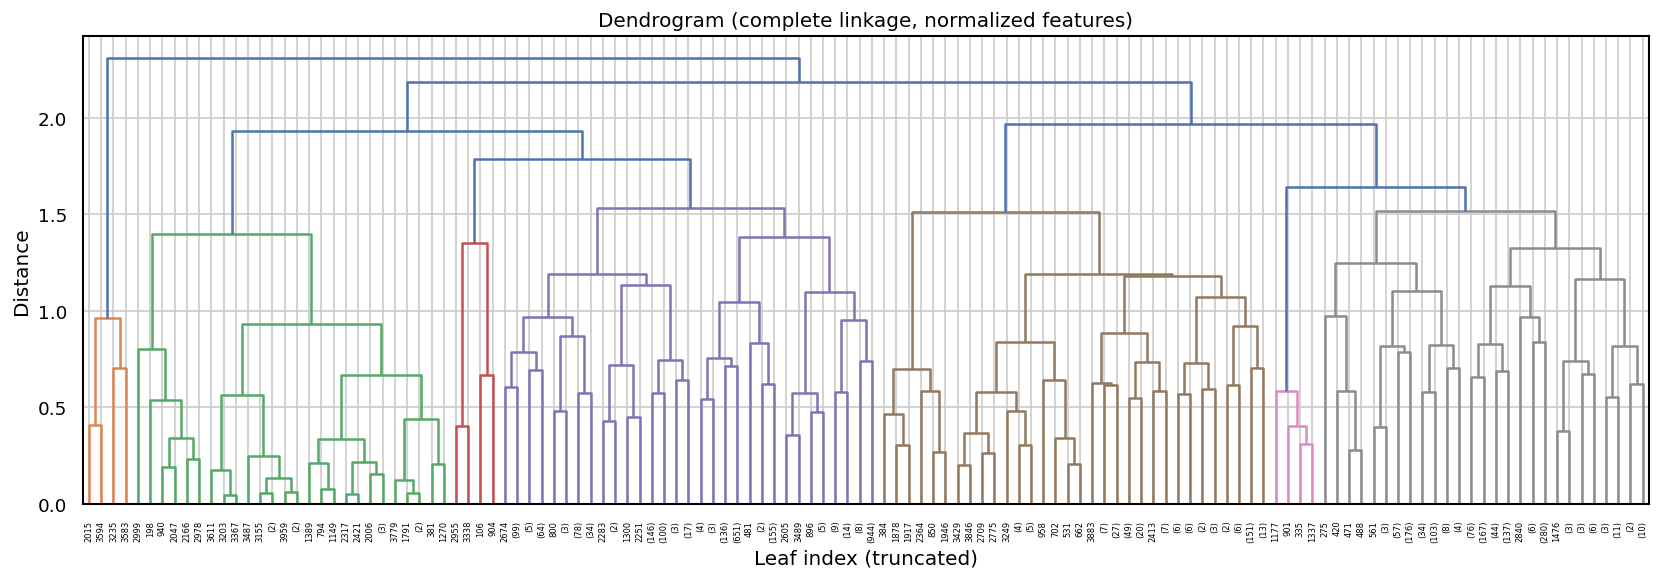

Hierarchical cluster counts: (array([0, 1]), array([3995,    4]))
Silhouette (K=2, hierarchical labels, Euclidean): 0.4704


In [ ]:
airlines = pd.read_excel(AIRLINE_XLSX, sheet_name="data")
airlines_clu = airlines.drop(columns=["ID#"])
feature_cols = airlines_clu.columns.tolist()

scaler_mm = MinMaxScaler()
data_norm = scaler_mm.fit_transform(airlines_clu)

link_mat = linkage(data_norm, method="complete")
plt.figure(figsize=(14, 5))
dendrogram(link_mat, truncate_mode="level", p=8)
plt.title("Dendrogram (complete linkage, normalized features)")
plt.xlabel("Leaf index (truncated)")
plt.ylabel("Distance")
plt.tight_layout()
savefig("fig_hc_dendrogram_full.png")
plt.show()

hc = AgglomerativeClustering(n_clusters=2, linkage="complete")
hc_labels = hc.fit_predict(data_norm)
sil_hc = silhouette_score(data_norm, hc_labels)
print("Hierarchical cluster counts:", np.unique(hc_labels, return_counts=True))
print(f"Silhouette (K=2, hierarchical labels, Euclidean): {sil_hc:.4f}")
REPORT_METRICS["hierarchical"] = {"silhouette_k2": float(sil_hc)}

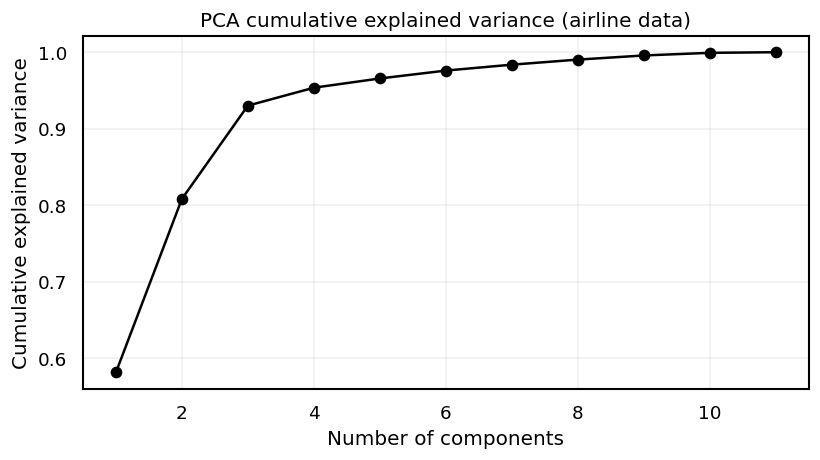

In [ ]:
pca_full = PCA(random_state=0).fit(data_norm)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o", color="black")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance (airline data)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
savefig("fig_pca_cumulative_variance.png")
plt.show()

REPORT_METRICS["pca"] = {
    "variance_first_two_components": float(np.sum(pca_full.explained_variance_ratio_[:2])),
    "n_features": int(data_norm.shape[1]),
}

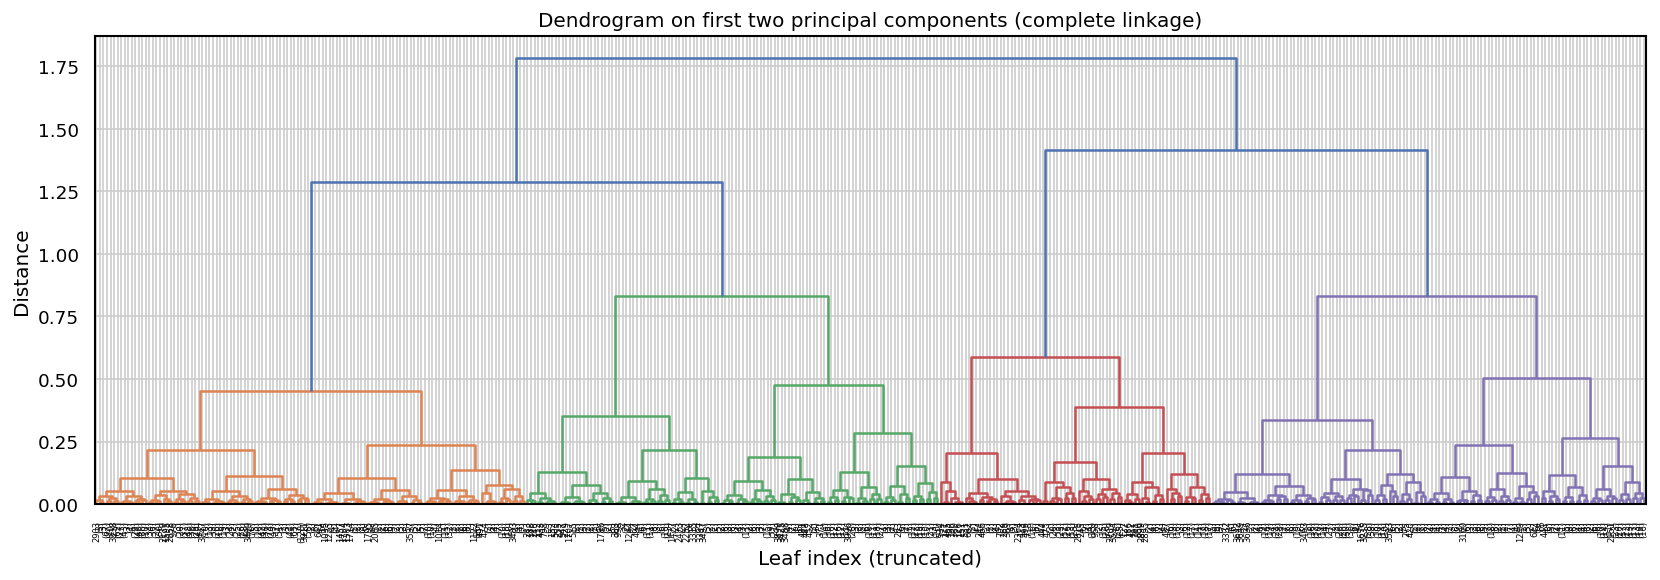

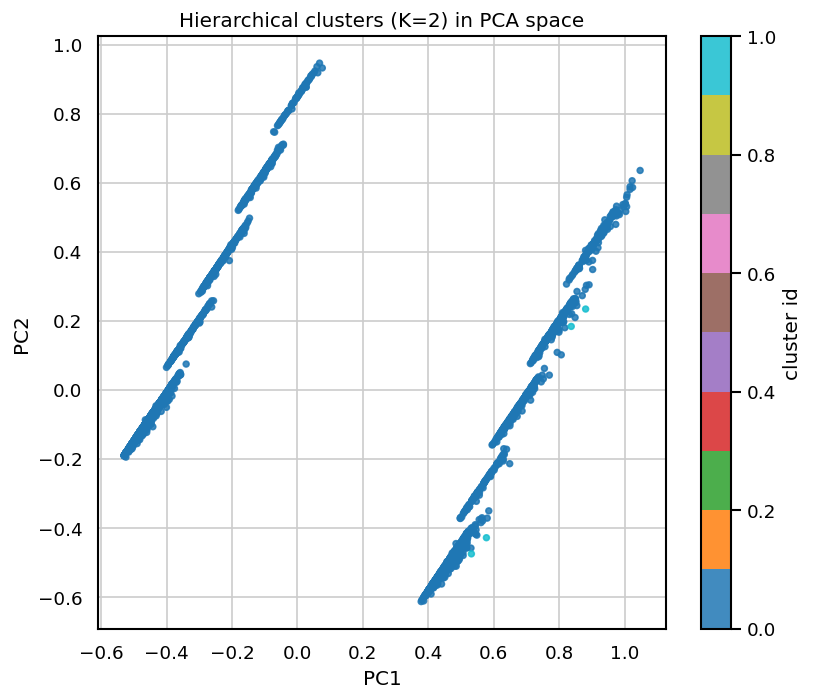

In [ ]:
pca2 = PCA(n_components=2, random_state=0)
Z2 = pca2.fit_transform(data_norm)

link_z = linkage(Z2, method="complete")
plt.figure(figsize=(14, 5))
dendrogram(link_z, truncate_mode="level", p=8)
plt.title("Dendrogram on first two principal components (complete linkage)")
plt.xlabel("Leaf index (truncated)")
plt.ylabel("Distance")
plt.tight_layout()
savefig("fig_hc_dendrogram_pca2.png")
plt.show()

plt.figure(figsize=(7, 6))
scatter = plt.scatter(Z2[:, 0], Z2[:, 1], c=hc_labels, cmap="tab10", s=12, alpha=0.85)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical clusters (K=2) in PCA space")
plt.colorbar(scatter, label="cluster id")
plt.tight_layout()
savefig("fig_hc_pca_scatter.png")
plt.show()

### Hierarchical clustering Summary

Complete linkage uses the maximum between-cluster distance, which discourages the chaining seen under single linkage. The dendrogram on all features summarizes global merge order, while the dendrogram on two principal components shows how much of that structure survives aggressive linear compression. The silhouette score offers a single-number sanity check for how well-separated the two groups are in the original normalized space.

---

## Part D — K-means  with normalized data

The elbow plot relates `K` to inertia (within-cluster sum of squared distances). The homework then fixes `K=2`, which permits a direct comparison to hierarchical clustering. `random_state` and `n_init=10` improve reproducibility and reduce sensitivity to random initialization.


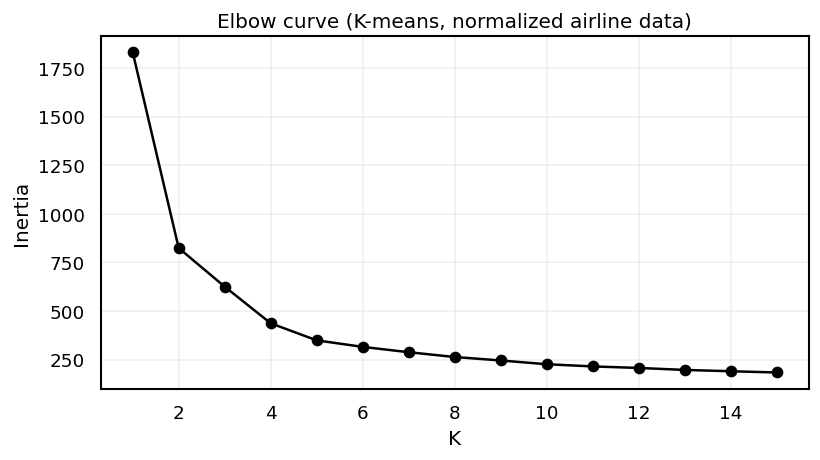

K-means cluster counts: (array([0, 1], dtype=int32), array([2518, 1481]))
Silhouette (K=2, K-means labels): 0.5359


In [ ]:
Ks = range(1, 16)
inertias = []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=KMEANS_RANDOM_STATE, n_init=10)
    km.fit(data_norm)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(Ks), inertias, marker="o", color="black")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow curve (K-means, normalized airline data)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
savefig("fig_kmeans_elbow.png")
plt.show()

kmeans2 = KMeans(n_clusters=2, random_state=KMEANS_RANDOM_STATE, n_init=10)
kmeans2.fit(data_norm)
km_labels = kmeans2.labels_
centroids = kmeans2.cluster_centers_
sil_km = silhouette_score(data_norm, km_labels)
print("K-means cluster counts:", np.unique(km_labels, return_counts=True))
print(f"Silhouette (K=2, K-means labels): {sil_km:.4f}")
REPORT_METRICS["kmeans"] = {"silhouette_k2": float(sil_km)}

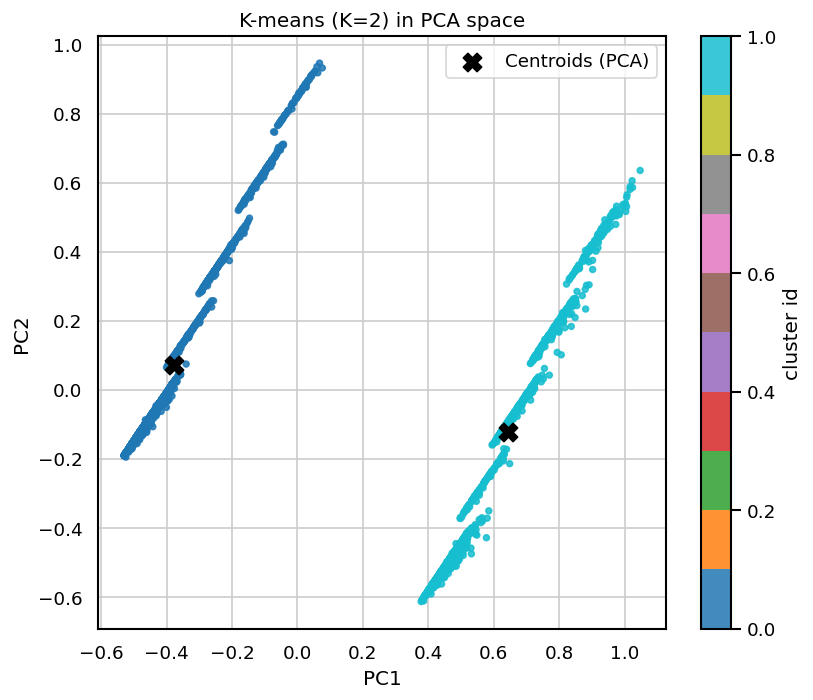

In [ ]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(Z2[:, 0], Z2[:, 1], c=km_labels, cmap="tab10", s=12, alpha=0.85)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means (K=2) in PCA space")
plt.colorbar(scatter, label="cluster id")
centroids_pca = pca2.transform(centroids)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c="black", marker="X", s=120, label="Centroids (PCA)")
plt.legend()
plt.tight_layout()
savefig("fig_kmeans_pca_scatter.png")
plt.show()

### K-means Summary

K-means assumes roughly spherical clusters with comparable variance. If the elbow is gradual, the choice of `K` should still be supported by domain knowledge; here `K=2` is fixed by the assignment. Comparing the PCA scatter colored by hierarchical labels versus K-means labels shows whether both algorithms recover a similar partition of the airline loyalty feature space.

---

## Part E — kNN on the UCI Wisconsin Breast Cancer Original dataset

The original CSV includes an ID column and missing values. Rows are split before exploratory plots on the training fold only, so the test patients never influence the exploratory views. Median imputation is fit on the training set only and applied to both partitions to avoid leakage. `StandardScaler` is applied for the same reason: kNN uses Euclidean distance, so features must live on comparable scales.

It sweeps odd `k` from 3 through 9. Additionally compares `weights="uniform"` against `weights="distance"`, which often improves accuracy when nearby neighbors vary in reliability. The combination with highest test accuracy is selected for final reporting, followed by the requested precision, recall, F1, confusion matrix, and ROC analysis.


In [ ]:
cols = [
    "sample_code",
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class",
]
df_uci = pd.read_csv(UCI_BC_URL, header=None, names=cols)
for c in df_uci.columns:
    if c not in ("sample_code", "class"):
        df_uci[c] = pd.to_numeric(df_uci[c], errors="coerce")

X_raw = df_uci.drop(columns=["sample_code", "class"])
y_raw = df_uci["class"].map({2: 0, 4: 1})

Xu_train, Xu_test, yu_train, yu_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE_SPLIT, stratify=y_raw
)

imputer = SimpleImputer(strategy="median")
Xu_train_imp = imputer.fit_transform(Xu_train)
Xu_test_imp = imputer.transform(Xu_test)

scaler = StandardScaler()
Xu_train_s = scaler.fit_transform(Xu_train_imp)
Xu_test_s = scaler.transform(Xu_test_imp)

display(Xu_train.head())

,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses
569,10,10,8,10,6,5.0,10,3,1
443,1,1,1,1,2,2.0,1,1,1
135,5,1,1,1,2,2.0,3,3,1
396,3,1,1,1,2,1.0,3,1,1
546,6,10,10,10,4,10.0,7,10,1


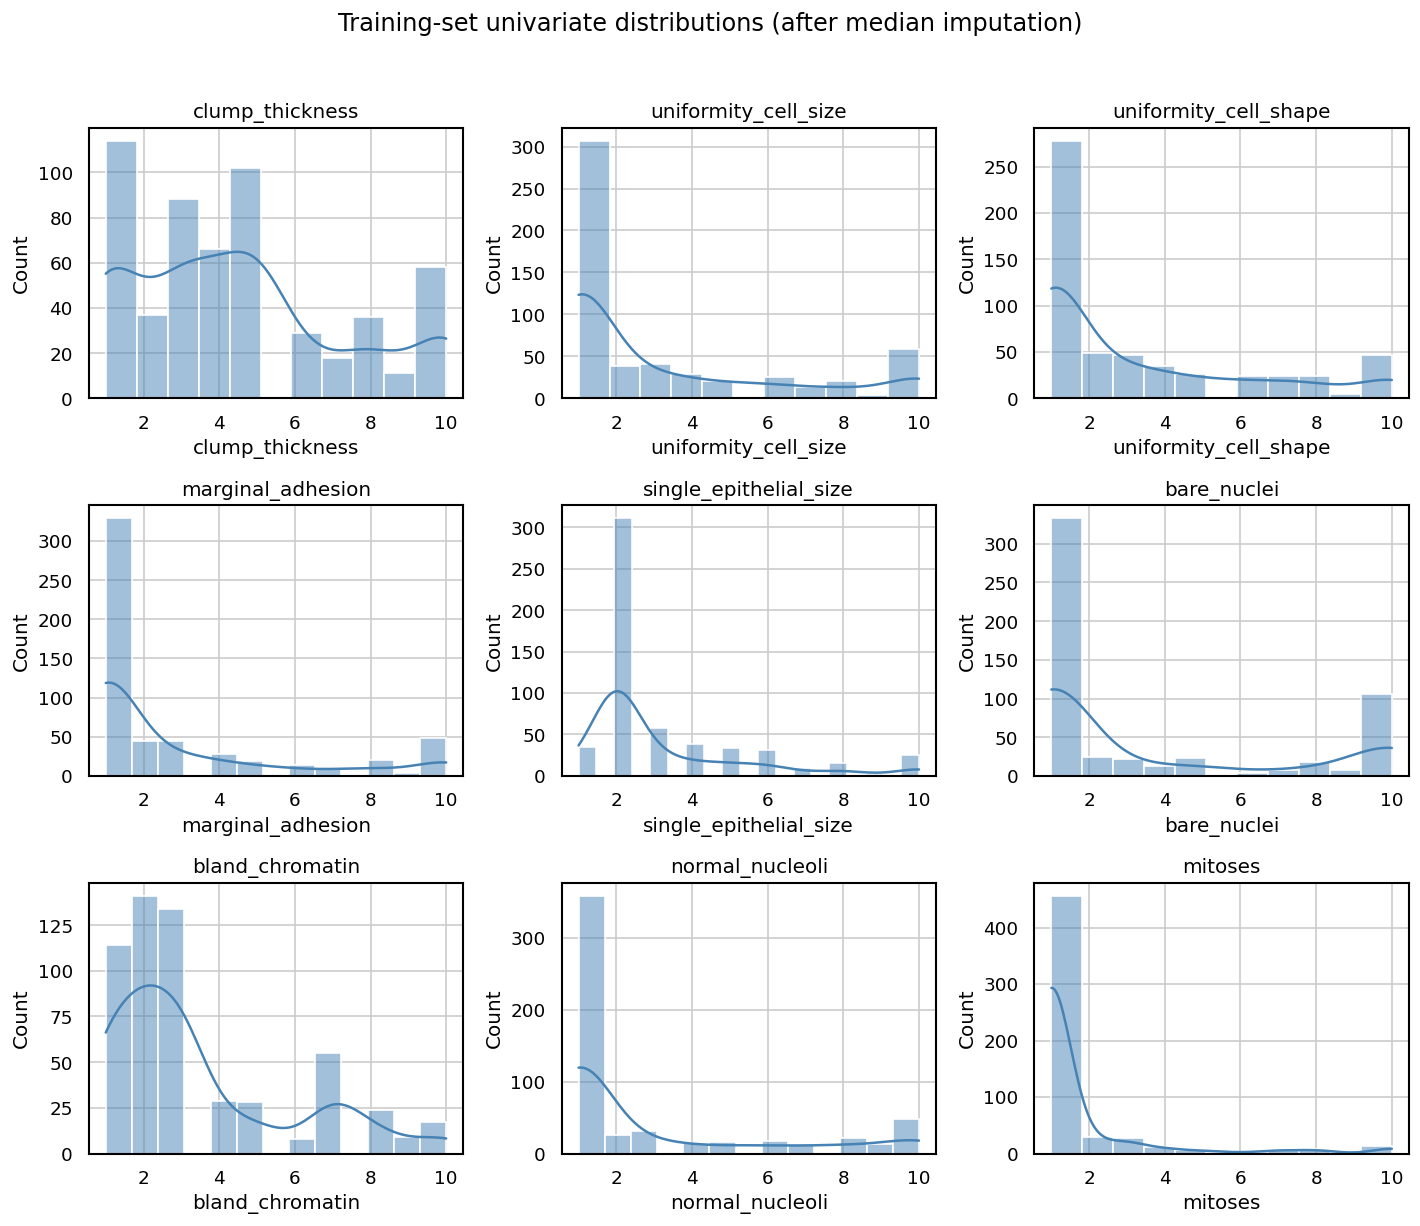

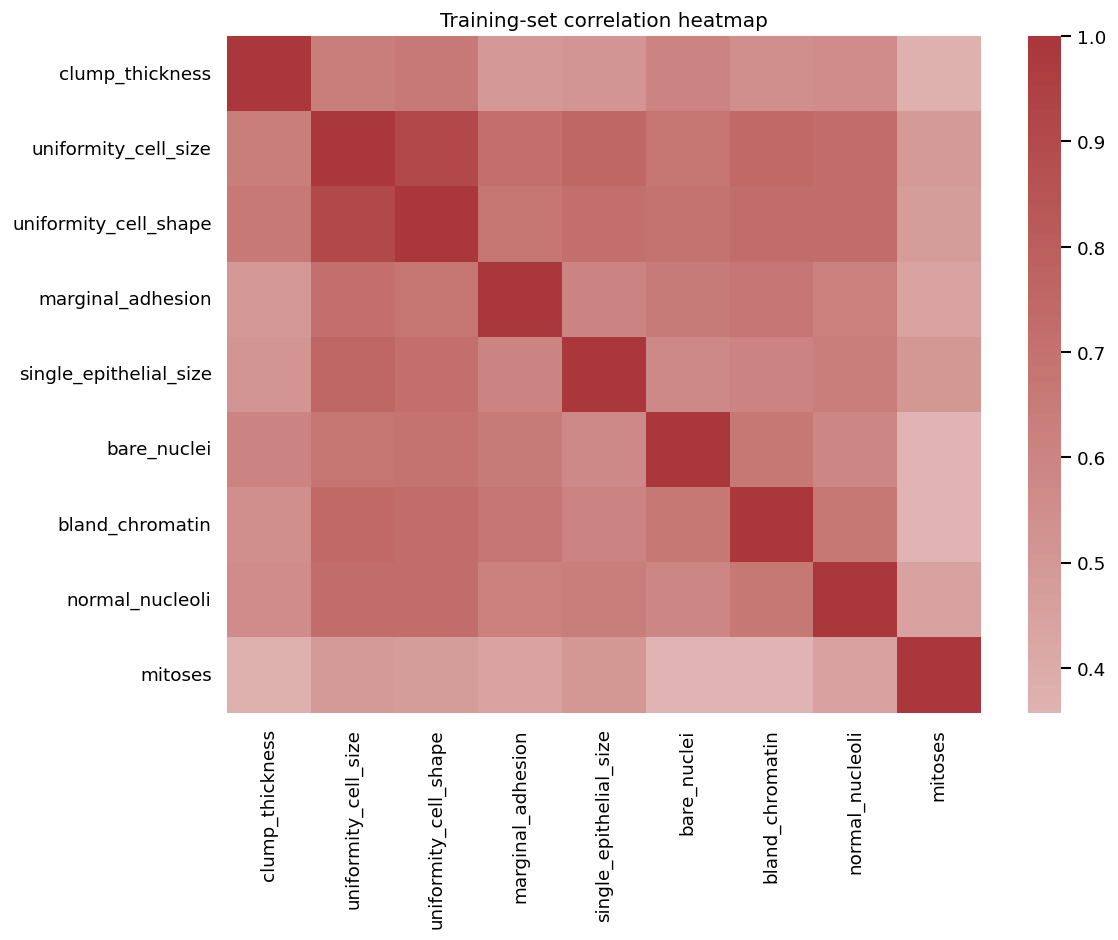

In [ ]:
X_train_df = pd.DataFrame(Xu_train_imp, columns=X_raw.columns)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.ravel()
for i, c in enumerate(X_raw.columns):
    sns.histplot(X_train_df[c], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(c)
for j in range(len(X_raw.columns), len(axes)):
    axes[j].axis("off")
plt.suptitle("Training-set univariate distributions (after median imputation)", y=1.02)
plt.tight_layout()
savefig("fig_knn_univariate_train.png")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(X_train_df.corr(numeric_only=True), annot=False, cmap="vlag", center=0)
plt.title("Training-set correlation heatmap")
plt.tight_layout()
savefig("fig_knn_corr_train.png")
plt.show()

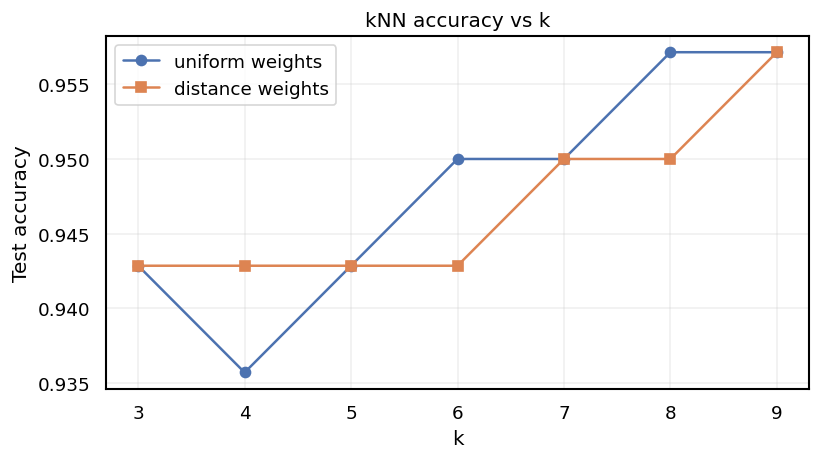

Selected k=8, weights=uniform, test accuracy=0.9571
              precision    recall  f1-score   support

      benign       0.97      0.97      0.97        92
   malignant       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



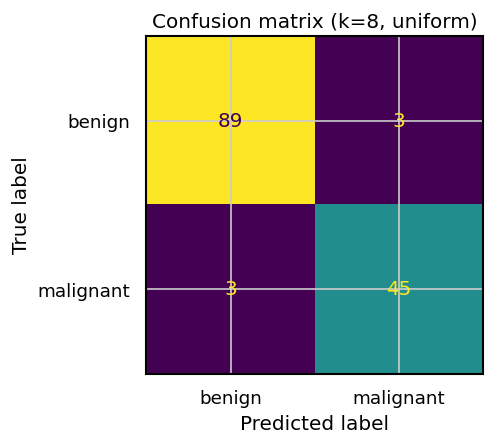

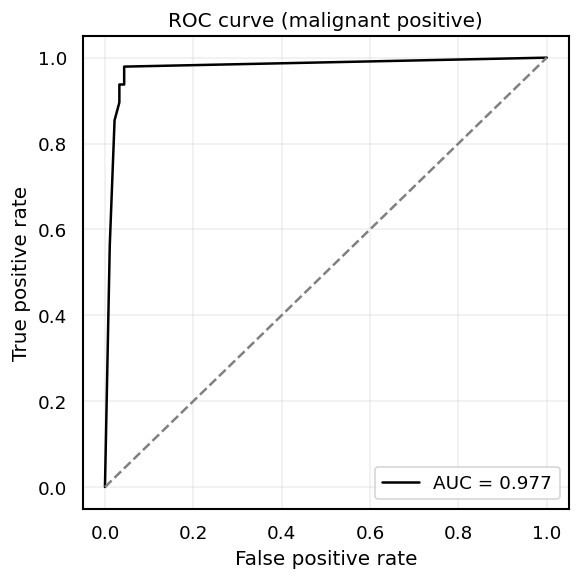

Created _hw3_report_out/metrics.json


In [ ]:
ks = list(range(3, 10))
weights_list = ["uniform", "distance"]
acc_grid = {w: [] for w in weights_list}
for w in weights_list:
    for k in ks:
        knn = KNeighborsClassifier(n_neighbors=k, weights=w, p=2)
        knn.fit(Xu_train_s, yu_train)
        acc_grid[w].append(accuracy_score(yu_test, knn.predict(Xu_test_s)))

plt.figure(figsize=(7, 4))
plt.plot(ks, acc_grid["uniform"], marker="o", label="uniform weights")
plt.plot(ks, acc_grid["distance"], marker="s", label="distance weights")
plt.xticks(ks)
plt.xlabel("k")
plt.ylabel("Test accuracy")
plt.title("kNN accuracy vs k")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
savefig("fig_knn_accuracy_vs_k.png")
plt.show()

best_score = -1.0
best_k = ks[0]
best_w = "uniform"
for w in weights_list:
    for k, acc in zip(ks, acc_grid[w]):
        if acc > best_score:
            best_score = acc
            best_k = k
            best_w = w

knn_best = KNeighborsClassifier(n_neighbors=best_k, weights=best_w, p=2)
knn_best.fit(Xu_train_s, yu_train)
yu_pred = knn_best.predict(Xu_test_s)
yu_prob = knn_best.predict_proba(Xu_test_s)[:, 1]

print(f"Selected k={best_k}, weights={best_w}, test accuracy={best_score:.4f}")
print(classification_report(yu_test, yu_pred, target_names=["benign", "malignant"]))

fig, ax = plt.subplots(figsize=(4.2, 4))
cm = confusion_matrix(yu_test, yu_pred)
ConfusionMatrixDisplay(cm, display_labels=["benign", "malignant"]).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix (k={best_k}, {best_w})")
plt.tight_layout()
savefig("fig_knn_confusion_best.png")
plt.show()

fpr, tpr, _ = roc_curve(yu_test, yu_prob)
auc = roc_auc_score(yu_test, yu_prob)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color="black", label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (malignant positive)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
savefig("fig_knn_roc.png")
plt.show()

REPORT_METRICS["knn"] = {
    "best_k": int(best_k),
    "best_weights": best_w,
    "test_accuracy": float(best_score),
    "test_roc_auc": float(auc),
    "precision_malignant": float(precision_score(yu_test, yu_pred, pos_label=1, zero_division=0)),
    "recall_malignant": float(recall_score(yu_test, yu_pred, pos_label=1, zero_division=0)),
    "f1_malignant": float(f1_score(yu_test, yu_pred, pos_label=1, zero_division=0)),
}

with open(REPORT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(REPORT_METRICS, f, indent=2)

print("Created", REPORT_DIR / "metrics.json")

### kNN Summary

Distance weighting lets closer neighbors influence the vote more strongly, which often helps when the decision boundary is irregular. Median imputation on the training fold only keeps missing-value statistics from peeking at the test fold. After scaling, the ROC curve and AUC summarize how well malignant cases are ranked above benign cases across thresholds, which complements the accuracy-maximizing choice of `k` at a fixed 0.5 decision rule.
